#### What is Boosting and Gradient Boosting?
+ Boosting : an ensemble technique of adding new models to correct the errors made by existing models. It is an ensemble method that seeks to create a strong classifier (model) based on “weak” classifiers.
+ By adding models on top of each other iteratively, the errors of the previous model are corrected by the next predictor, until the training data is accurately predicted or reproduced by the model.
+ Gradient Boosting: an ensemble method that sequentially adds predictors and corrects previous models.
+ Procedure: instead of assigning different weights to the classifiers after every iteration, this method fits the new model to new residuals of the previous prediction and then minimizes the loss when adding the latest prediction

#### Note:
+ Has a DMatrix( for performance and efficiency)
+ Works with only numerical values
+ For Categorical you need to one-hot-encode it/label encode it

#### Reasons For using XGBoost
+ Execution Speed
+ Model Performance.

#### Workflow
+ Load data
        =>OnehotEncode Cat
        =>Split
        =>Model Initializing
        =>Fitting
        =>Predict
 + Load data
     => Convert to DxMatrix
     => Cross validation
     => Train
     => Predict
     => Plot


In [1]:
# Load Pkgs
import pandas as pd
import numpy as np
import xgboost as xgb

In [2]:
# Load Dataset (California Housing)
df = pd.read_csv("bank-additional-full.csv",sep=";")

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Shape
df.shape

(41188, 21)

In [5]:
# Columns
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [6]:
# Check Missing Values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [7]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [8]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

### Encode our categorical data
+ Category
+ Get Dummies
+ LabelEncoder/ LabelBinarizer
+ Custom Find and Replace


In [10]:
# Get All Columns that are object
df.columns[df.dtypes == 'object']

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [11]:
#Using Get Dummies
pd.get_dummies(df,df.columns[df.dtypes == 'object'])

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y_no,y_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True


In [12]:
# Check For Unique Values of Each Column
for i in df.columns[df.dtypes == 'object']:
    print(i,"::",df[i].unique())

job :: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital :: ['married' 'single' 'divorced' 'unknown']
education :: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default :: ['no' 'unknown' 'yes']
housing :: ['no' 'yes' 'unknown']
loan :: ['no' 'yes' 'unknown']
contact :: ['telephone' 'cellular']
month :: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week :: ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome :: ['nonexistent' 'failure' 'success']
y :: ['no' 'yes']


In [13]:
df2 = df

In [14]:
# Using Categorical dtypes
for i in df.columns[df.dtypes == 'object']:
    print(i,"::")
    df2[i] = df[i].astype('category')
    df2[i] = df2[i].cat.codes


job ::
marital ::
education ::
default ::
housing ::
loan ::
contact ::
month ::
day_of_week ::
poutcome ::
y ::


In [15]:
df2.job.head()

,job
0,3
1,7
2,7
3,0
4,7


In [16]:
df2.job.unique()

array([ 3,  7,  0,  1,  9,  5,  4, 10,  6, 11,  2,  8], dtype=int8)

In [17]:
df2.dtypes

,0
age,int64
job,int8
marital,int8
education,int8
default,int8
housing,int8
loan,int8
contact,int8
month,int8
day_of_week,int8


In [18]:
df2.y.unique()

array([0, 1], dtype=int8)

In [20]:
df2.shape

(41188, 21)

In [21]:
X= df2.iloc[:,0:20]

In [22]:
X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,3,1,0,0,0,0,1,6,1,261,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
1,57,7,1,3,1,0,0,1,6,1,149,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
2,37,7,1,3,0,2,0,1,6,1,226,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
3,40,0,1,1,0,0,0,1,6,1,151,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
4,56,7,1,3,0,0,2,1,6,1,307,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0


In [23]:
y = df2['y']

In [24]:
# Split dataset
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [26]:
X_train.shape

(32950, 20)

#### Building Models

In [27]:
#load Gradient Boosting From Sklearn
from sklearn.ensemble import GradientBoostingClassifier

In [28]:
GB_classifier=GradientBoostingClassifier()
GB_classifier.fit(X_train,y_train)

GradientBoostingClassifier()

In [29]:
y_predictions = GB_classifier.predict(X_test)

In [30]:
y_predictions

array([0, 0, 0, ..., 1, 0, 0], dtype=int8)

In [31]:
# Load Accuracy Score
from sklearn.metrics import accuracy_score

In [32]:
print("Accuracy of Model::",accuracy_score(y_test,y_predictions))

Accuracy of Model:: 0.9248604030104395


In [33]:
GB_classifier.score(X_test,y_test)

0.9248604030104395

### Using Decision tree classifier

In [34]:
# Load Pkg
from sklearn.tree import DecisionTreeClassifier

In [35]:
dTree_clf = DecisionTreeClassifier()

In [36]:
dTree_clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [37]:
# Prediction
y_pred2 = dTree_clf.predict(X_test)

In [38]:
y_pred2

array([1, 0, 0, ..., 1, 0, 0], dtype=int8)

In [39]:
print("Accuracy of Model::",accuracy_score(y_test,y_pred2))

Accuracy of Model:: 0.8906287933964554


### Using XGBoost

In [40]:
xgb_classifier = xgb.XGBClassifier()

In [41]:
xgb_classifier.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [42]:
predictions = xgb_classifier.predict(X_test)

In [43]:
predictions

array([1, 0, 0, ..., 1, 0, 0])

In [44]:
print("Accuracy of Model::",accuracy_score(y_test,predictions))

Accuracy of Model:: 0.922068463219228


In [45]:
# prompt: can we add lasso regularization to the above xgboost model so that it can classify better

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Lasso

# ... (Your existing code) ...

# ### Using XGBoost with Lasso regularization (indirectly)

# 1. Feature Importance from XGBoost
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train, y_train)
predictions = xgb_classifier.predict(X_test)
print("Accuracy of Model (XGBoost):", accuracy_score(y_test, predictions))

feature_importances = xgb_classifier.feature_importances_

# 2. Apply Lasso regularization to the most important features
#    (This is an indirect way to use Lasso with XGBoost)
important_features_indices = np.argsort(feature_importances)[::-1][:10] # Select top 10
important_features = X_train.columns[important_features_indices]
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]


lasso = Lasso(alpha=0.1) # You can tune alpha
lasso.fit(X_train_important, y_train)
lasso_predictions = lasso.predict(X_test_important)

# Convert Lasso predictions to binary (0 or 1)
lasso_predictions_binary = np.where(lasso_predictions > 0.5, 1, 0) # Adjust threshold if needed


print("Accuracy of Model (Lasso on important features):", accuracy_score(y_test, lasso_predictions_binary))

# ... (Rest of your code) ...


Accuracy of Model (XGBoost): 0.922068463219228
Accuracy of Model (Lasso on important features): 0.9054382131585337


In [46]:
# Load Data Viz Pkgs
import matplotlib.pyplot as plt
%matplotlib inline

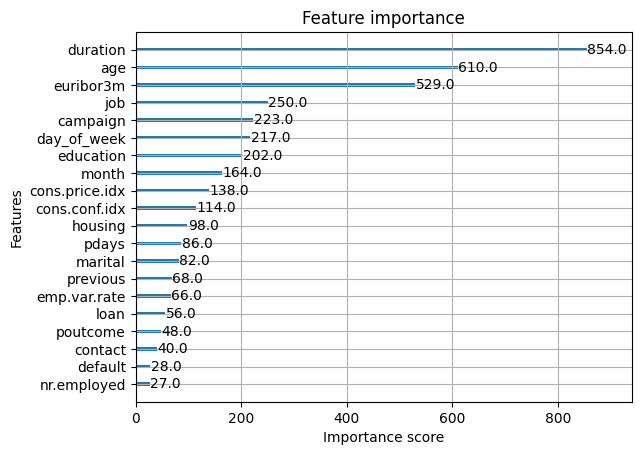

In [47]:
# Feature Importance
xgb.plot_importance(xgb_classifier)
plt.rcParams['figure.figsize'] = [5, 5]
plt.show()